# LightGBM Model

This notebook aims to build LightGBM Model.

## 0. Import Libraries


In [1]:
# Data Analysis Libraries
import pandas as pd 
import numpy as np 
from IPython.display import HTML, display 
from pprint import pprint

# Data Visualization Libraries 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Machine Learning Libraries
import lightgbm as lgb
from sklearn.model_selection import train_test_split

# Data Preparation and Evaluation Libraries
import src.data_preprocess as dp
import src.evaluation as ev

print(f"Current pandas version: {pd.__version__}")
print(f"Current LightGBM version: {lgb.__version__}")

Current pandas version: 2.0.3
Current LightGBM version: 4.6.0


In [ ]:
# - MLFlow Experiment Tracking -
import mlflow 

def set_or_create_experiment(name: str):
	exp = mlflow.get_experiment_by_name(name)
	if exp is None:
		mlflow.create_experiment(name)
		print(f"✅ Experiment '{name}' created.")

	mlflow.set_experiment(name)
	print(f"✅ Current experiment set to '{name}'.")


set_or_create_experiment("LightGBM Runs")
mlflow.lightgbm.autolog()
mlflow.sklearn.autolog()
print("✅ MLFlow autologging for LightGBM is enabled.")

✅ Current experiment set to 'LightGBM Runs'.
✅ MLFlow autologging for LightGBM is enabled.


## 1. Read Data


In [3]:
df1 = pd.read_csv("data/processed/creditcard_cleaned.csv")
df1.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Stratified Splitting


In [4]:
X = df1.drop(columns=['Class'])
y = df1['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
# - Check Class Distribution - 
print(y_train.value_counts() )
print(y_test.value_counts())

Class
0    226602
1       378
Name: count, dtype: int64
Class
0    56651
1       95
Name: count, dtype: int64


## 3. Feature Scaling


In [6]:
# - Scaling of Train, Validation, Test Data  - 
from sklearn.preprocessing import StandardScaler, RobustScaler
scaler = RobustScaler().set_output(transform="pandas")

# - Train StandardScaler() based on features in Train Data - 
X_train_scaled = scaler.fit_transform(X_train)

# - Apply Learning to Test Data - 
X_test_scaled = scaler.transform(X_test)

pd.set_option('display.max_columns', None)
display(X_train_scaled.describe(), X_test_scaled.describe())



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,226980.000000,226980.000000,226980.000000,2.269800e+05,2.269800e+05,226980.000000,2.269800e+05,226980.000000,2.269800e+05,2.269800e+05,226980.000000,2.269800e+05,226980.000000,2.269800e+05,2.269800e+05,226980.000000,226980.000000,2.269800e+05,2.269800e+05,2.269800e+05,2.269800e+05,2.269800e+05,2.269800e+05,226980.000000,2.269800e+05,2.269800e+05,2.269800e+05,226980.000000,226980.000000,226980.000000
mean,0.118467,-0.005974,-0.049463,-9.201113e-02,1.255679e-02,0.044015,2.349303e-01,-0.034999,-4.202809e-02,4.031268e-02,0.092410,2.092558e-02,-0.135105,9.465147e-03,-5.495478e-02,-0.039242,-0.067715,7.378956e-02,3.413561e-03,-4.556527e-03,1.819526e-01,7.178829e-02,-6.866841e-03,0.035958,-5.167418e-02,-2.380088e-02,9.178721e-02,0.001125,-0.079995,0.918890
std,0.557881,0.872721,1.176252,7.872012e-01,8.907940e-01,1.042265,1.134854e+00,1.067395,2.189368e+00,8.833613e-01,1.083991,6.783285e-01,0.971498,7.587327e-01,1.038662e+00,0.743217,0.882168,9.570856e-01,8.371572e-01,8.891543e-01,2.200688e+00,1.740203e+00,6.766285e-01,2.014884,7.621087e-01,7.798472e-01,8.495508e-01,2.412071,2.479393,3.405863
min,-0.996399,-25.288450,-51.895128,-1.768367e+01,-3.558984e+00,-24.560719,-2.219678e+01,-38.774475,-1.371258e+02,-1.080429e+01,-24.740607,-3.173772e+00,-18.298694,-4.410958e+00,-2.096634e+01,-3.697117,-14.336465,-2.848973e+01,-9.495503e+00,-7.888350e+00,-6.833706e+01,-8.385150e+01,-1.021956e+01,-144.253529,-3.620168e+00,-1.541592e+01,-4.505273e+00,-139.366693,-89.223071,-0.305987
25%,-0.359179,-0.418701,-0.474124,-5.565134e-01,-5.200782e-01,-0.488053,-4.226226e-01,-0.527684,-4.322513e-01,-4.775868e-01,-0.446674,-4.862148e-01,-0.531611,-4.851090e-01,-5.182132e-01,-0.512350,-0.540332,-4.750870e-01,-4.965198e-01,-5.028997e-01,-4.328936e-01,-4.804289e-01,-5.128786e-01,-0.486354,-4.980661e-01,-4.991125e-01,-4.850961e-01,-0.444802,-0.487763,-0.227134
50%,0.000000,0.000000,0.000000,7.248908e-18,-1.090131e-18,0.000000,-2.380163e-17,0.000000,-3.247948e-18,-2.801138e-18,0.000000,2.310706e-18,0.000000,-6.623798e-19,-3.776205e-18,0.000000,0.000000,7.877406e-18,1.084202e-19,4.739149e-19,-1.005269e-17,4.179578e-18,-4.050935e-19,0.000000,4.364549e-18,-2.593403e-18,6.122354e-18,0.000000,0.000000,0.000000
75%,0.640821,0.581299,0.525876,4.434866e-01,4.799218e-01,0.511947,5.773774e-01,0.472316,5.677487e-01,5.224132e-01,0.553326,5.137852e-01,0.468389,5.148910e-01,4.817868e-01,0.487650,0.459668,5.249130e-01,5.034802e-01,4.971003e-01,5.671064e-01,5.195711e-01,4.871214e-01,0.513646,5.019339e-01,5.008875e-01,5.149039e-01,0.555198,0.512237,0.772866
max,1.033522,1.092001,15.682657,4.807100e+00,1.062278e+01,26.718231,1.858179e+01,30.471631,3.741801e+01,1.263434e+01,24.078235,8.024285e+00,7.548203,3.497499e+00,1.140431e+01,4.695650,7.058798,1.057889e+01,5.041094e+00,6.083943e+00,1.144026e+02,6.561204e+01,9.803975e+00,72.582873,5.000781e+00,1.121771e+01,6.298669e+00,75.039553,257.540705,272.096037


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000
mean,0.113231,-0.003980,-0.044423,-0.093364,0.009599,0.032082,0.238452,-0.033571,-0.048015,0.045509,0.096142,0.021332,-0.138831,0.014336,-0.044714,-0.038634,-0.068547,0.078304,-0.000376,-0.009845,0.175263,0.054453,-0.007278,0.042859,-0.050590,-0.027381,0.090403,0.003642,-0.095226,0.924819
std,0.557445,0.874368,1.165828,0.790887,0.882038,1.107183,1.170976,1.184582,2.278849,0.889145,1.100038,0.678528,0.982750,0.764100,1.027296,0.745676,0.882343,0.953627,0.837333,0.887724,2.348528,1.760020,0.677495,1.982522,0.760925,0.776761,0.855430,2.567627,2.564886,3.715792
min,-0.996376,-16.840672,-27.358936,-25.332104,-3.391221,-87.152273,-18.568409,-29.598114,-94.945916,-8.711826,-21.064987,-2.716157,-18.425977,-2.903112,-19.699068,-3.296047,-13.502457,-24.570406,-9.087740,-5.053059,-157.727687,-55.080637,-6.644623,-118.035448,-3.532122,-10.059626,-2.936521,-61.118690,-117.531159,-0.305987
25%,-0.361326,-0.418996,-0.471600,-0.561773,-0.523038,-0.489962,-0.423449,-0.527689,-0.434304,-0.477310,-0.444916,-0.486816,-0.536814,-0.482081,-0.509679,-0.513796,-0.541132,-0.473709,-0.497599,-0.507988,-0.431094,-0.483419,-0.517839,-0.475431,-0.495680,-0.497567,-0.486766,-0.447783,-0.494365,-0.229906
50%,-0.004065,0.004787,0.000498,0.004239,-0.000770,-0.004294,0.002639,0.000059,-0.003020,0.003104,0.002172,-0.002586,0.004742,0.000499,0.007718,0.000738,-0.007238,-0.001444,-0.005386,-0.007891,-0.002453,-0.009434,-0.003070,0.004725,-0.000633,0.000893,-0.004452,-0.000872,-0.007033,-0.006860
75%,0.636953,0.582886,0.522292,0.442669,0.474417,0.500292,0.574122,0.465906,0.569995,0.529935,0.550162,0.511724,0.471186,0.521407,0.485348,0.491106,0.458927,0.535109,0.501426,0.489544,0.562270,0.511902,0.484464,0.507367,0.499638,0.497589,0.517223,0.549261,0.494575,0.754123
max,1.033452,1.081056,11.860807,1.956759,9.635044,25.269252,63.094880,107.211413,29.529848,8.434062,13.876111,7.497928,4.342747,5.449921,8.387040,7.176662,17.414621,10.526140,4.054706,6.105645,70.108303,48.411126,7.720137,61.230126,5.715579,7.164033,6.203194,195.216185,120.680145,355.724501


In [7]:
# - Check Scaling Validity Manually - 
dp.check_scaling_validity(X_train_scaled)
dp.check_scaling_validity(X_test_scaled)

✅ Feature means after scaling:
 Time      0.118467
V1       -0.005974
V2       -0.049463
V3       -0.092011
V4        0.012557
V5        0.044015
V6        0.234930
V7       -0.034999
V8       -0.042028
V9        0.040313
V10       0.092410
V11       0.020926
V12      -0.135105
V13       0.009465
V14      -0.054955
V15      -0.039242
V16      -0.067715
V17       0.073790
V18       0.003414
V19      -0.004557
V20       0.181953
V21       0.071788
V22      -0.006867
V23       0.035958
V24      -0.051674
V25      -0.023801
V26       0.091787
V27       0.001125
V28      -0.079995
Amount    0.918890
dtype: float64
-----------------------------------

✅ Feature std devs after scaling:
 Time      0.557881
V1        0.872721
V2        1.176252
V3        0.787201
V4        0.890794
V5        1.042265
V6        1.134854
V7        1.067395
V8        2.189368
V9        0.883361
V10       1.083991
V11       0.678329
V12       0.971498
V13       0.758733
V14       1.038662
V15       0.743217
V16    

## 4. LightGBM Model (Stratified K-Fold Validation)


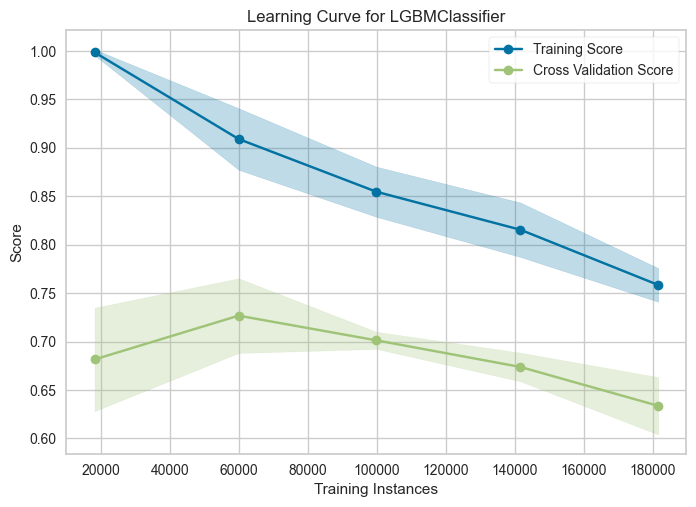

In [ ]:
# - Import SMOTE, Stratified K-Fold CV, LightGBM - 
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline  # Changed from sklearn.pipeline for SMOTE compatibility
from sklearn.metrics import log_loss
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from yellowbrick.model_selection import LearningCurve

from sklearn.metrics import infer_signature


# - Define Starting Parameters (removed early_stopping_round for cross-validation) - 
lightgbm_params={
      'objective': 'binary', # objective function: log loss 
      'max_depth': 5, 
      'n_jobs': -1,  # use all CPU Cores
      'random_state': 42, 
      'device_type': 'cpu', # can adjust to GPU
      'verbose': -1, 
      'force_col_wise': True
   }

# - Pipeline used for each Fold - 
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('lgbm', LGBMClassifier(**lightgbm_params))
])

# - Learning Curve Visualization with Stratified K-Fold CV -
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# - Custom Scorer for F2 Score (Prefer Recall over Precision) -
from sklearn.metrics import make_scorer, fbeta_score
scor = make_scorer(fbeta_score, beta=2) # default: 1 as pos class 


with mlflow.start_run(run_name="LightGBM_Baseline"):
    # - Train LightGBM, while plotting learning curves  - 
    visualizer = LearningCurve(
        pipeline,
        cv=cv,
        scoring=scor,  # Use F2 score for evaluation
        train_sizes=[0.1, 0.33, 0.55, 0.78, 1.0], # each fold at which part of X_train_scaled
        n_jobs=-1
    )
    visualizer.fit(X_train_scaled, y_train)  # Use scaled data
    visualizer.finalize()


✅ LGBM: CV Out-of-Fold Results Analysis
Accuracy:  0.9967
Precision: 0.3141
Recall:    0.8492
F1-Score:  0.4586
ROC-AUC:   0.9741
PR-AUC:    0.8068

✅ Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9969    0.9983    226602
           1     0.3141    0.8492    0.4586       378

    accuracy                         0.9967    226980
   macro avg     0.6569    0.9231    0.7284    226980
weighted avg     0.9986    0.9967    0.9974    226980

--------------------

✅ Confusion Matrix:


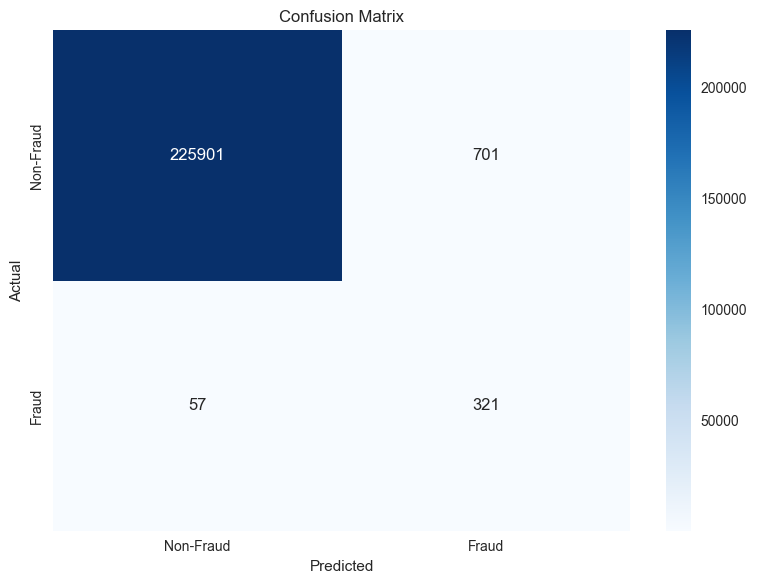

In [9]:
# Step 2: Compute Out-of-Fold Predictions for Metrics
from sklearn.model_selection import cross_val_predict

# For label predictions
y_pred = cross_val_predict(pipeline, X_train_scaled, y_train, cv=cv, method="predict", n_jobs=-1)

# For probability predictions (for ROC and PR curves)
y_pred_proba = cross_val_predict(pipeline, X_train_scaled, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

# Step 3: Analyze Predictions (your ResultsAnalyser class)

results = ev.ResultsAnalyser.analyze_predictions(
    y_true=y_train,
    y_pred=y_pred,
    y_pred_proba=y_pred_proba,
    class_labels=["Non-Fraud", "Fraud"],
    model_name="LGBM: CV Out-of-Fold"
)

In [10]:
# - Compute F2 Score -
from sklearn.model_selection import cross_val_score
score2 = cross_val_score(pipeline, X_train, y_train, scoring=scor, cv=cv)
mean_f2_score = np.mean(score2)
print("Cross Validation F2 Scores are: {}".format(score2))
print("Average Cross Validation F2 score: {}".format(mean_f2_score))


# - Output all evaluation metrics on Positive Class -
print("Evaluation Metrics") 
results['f2_score'] = mean_f2_score
results



Cross Validation F2 Scores are: [0.7398568  0.74592075 0.74938575 0.76749436 0.78886311]
Average Cross Validation F2 score: 0.7583041525847338
Evaluation Metrics


{'accuracy': 0.9966604987223544,
 'precision': 0.31409001956947163,
 'recall': 0.8492063492063492,
 'f1_score': 0.4585714285714286,
 'roc_auc': 0.9741305164139031,
 'pr_auc': 0.8068330347892846,
 'f2_score': 0.7583041525847338}

## 5. Pre-Tuning Conclusion

- Learning Curve Insights


## 6. Hyperparameter Tuning

We will be using Optuna for hyperparameter tuning to fix the issues identified with our model. With Bayesian Optimization, Optuna is better than Random Search & Grid Search due to its speed and effectiveness. Let's first define an objective function, before letting Optuna search through the defined search space to find the best hyperparameters. Based on my research from sources like Medium and Kaggle, I have collected a list of hyperparameters most likely to solve our model's issue. This objective function should attempt to optimise F1 Score & Recall concurrently (Multi-Objective Optuna Optimization).


In [11]:
# # Import required libraries for hyperparameter tuning
# import optuna
# from sklearn.metrics import f1_score, recall_score

In [12]:

# def objective(trial):
#   """
#   Objective function for optimizing LightGBM AUC
#   """
  
#   params = {
#         # Learning parameters
#         'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3), # random increments in search space 
#         'num_iterations': trial.suggest_int('num_iterations', 100, 1000),
        
#         # Tree structure parameters
#         'max_depth': trial.suggest_int('max_depth', 3, 12),
#         'num_leaves': trial.suggest_int('num_leaves', 10, 300),
#         'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 100),
#         'max_bin': trial.suggest_int('max_bin', 63, 512),
        
#         # Regularization parameters
#         'lambda_l1': trial.suggest_float('lambda_l1', 0.0, 10.0),
#         'lambda_l2': trial.suggest_float('lambda_l2', 0.0, 10.0),
#         'min_gain_to_split': trial.suggest_float('min_gain_to_split', 0.0, 5.0),
#         'path_smooth': trial.suggest_float('path_smooth', 0.0, 100.0),
        
#         # Sampling parameters
#         'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
#         'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
#         'bagging_freq': trial.suggest_int('bagging_freq', 0, 7),
        
#         # Boosting type
#         'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt', 'dart', 'goss']),
        
#         # Fixed parameters
#         'objective': 'binary',
#         'metric': 'binary_logloss',
#         'random_state': 42,
#         'n_jobs': -1,
#         'device_type': 'cpu',
#         'verbose': -1
#      }
  
#   # Define & Train LightGBM Model
#   model = lgb.LGBMClassifier(**params)
#   model.fit(X_train_resampled, y_train_resampled, 
#             eval_set=[(X_val_scaled, y_val)], 
#             eval_metric='binary_logloss',
#             early_stopping_rounds=100,
#             verbose=0)

#   # Evaluate on Validation Set (Mu)
#   y_pred = model.predict(X_val_scaled) # class labels
#   y_proba_val = model.predict_proba(X_val_scaled)[:,1] # actual probabilities predicted 
#   f1score = f1_score(y_val, y_pred, zero_division=0) # f1 score of positive class
#   recall = recall_score(y_val, y_pred, zero_division=0) # recall of positive class
#   return f1score, recall

# study = optuna.create_study(direction = 'maximize')
# study.optimize(objective,n_trials = 100)

## 7. Model Evaluation (Test Set)
